<a href="https://colab.research.google.com/github/pametoro/AppApoyoEmocional/blob/master/trabajo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# se importan las librerias necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import  SimpleImputer

In [2]:
#se carga el Dataset
df = pd.read_csv('Notas de estudiantes.csv')

In [3]:
#Mostramos cantidad de filas y columnas del dataset
df.shape

(188, 7)

In [4]:
# visualizamos los primeros 5 registros o filas del dataset
df.head()

,ID_Estudiante,Nombre,Carrera,Seccion,Nota_1,Nota_2,Nota_3
0,1000,Camila González,Ingeniería en Informática,C,5.35,4.43,5.55
1,1001,Pedro Sepúlveda,Ingeniería en Informática,C,6.48,NaN,4.67
2,1002,Andrés Martínez,Analista Programador,C,6.54,5.52,4.43
3,1003,Isidora Soto,Data Science,A,5.4,4.04,4.43
4,1004,Josefa Soto,Data Science,A,5.07,2.30,3.18


In [5]:
# Visualizamos las columnas (variables) del dataset, cantidad de valores no nulos y tipo de dato
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID_Estudiante  188 non-null    int64  
 1   Nombre         188 non-null    object 
 2   Carrera        188 non-null    object 
 3   Seccion        188 non-null    object 
 4   Nota_1         188 non-null    object 
 5   Nota_2         173 non-null    float64
 6   Nota_3         188 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 10.4+ KB


In [6]:
#Mostramos estadística descriptiva de las variables categóricas

df.describe(include=['O'])

,Nombre,Carrera,Seccion,Nota_1,Nota_3
count,188,188,188,188,188
unique,119,6,3,143,143
top,María Díaz,Ingeniería en Informática,C,-1,4.43
freq,4,41,65,5,5


In [7]:
#Mostramos estadística descriptiva de las variables numéricas

df.describe()

,ID_Estudiante,Nota_2
count,188.000000,173.000000
mean,1089.228723,4.441387
std,51.812247,1.169606
min,1000.000000,0.710000
25%,1044.750000,3.620000
50%,1089.500000,4.380000
75%,1133.250000,5.350000
max,1179.000000,8.290000


In [8]:
# Valores nulos
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().sum())

Total de valores nulos de ID_Estudiante = 0
Total de valores nulos de Nombre = 0
Total de valores nulos de Carrera = 0
Total de valores nulos de Seccion = 0
Total de valores nulos de Nota_1 = 0
Total de valores nulos de Nota_2 = 15
Total de valores nulos de Nota_3 = 0


In [9]:
#rellenamos las notas faltantes con 1
df['Nota_1'] = df['Nota_1'].fillna(1)
df['Nota_2'] = df['Nota_2'].fillna(1)
df['Nota_3'] = df['Nota_3'].fillna(1)

df['Nota_1'] = df['Nota_1'].astype(str).str.replace(',', '.').astype(float)
df['Nota_3'] = df['Nota_3'].astype(str).str.replace(',', '.').replace(['ausente', 'NR'], np.nan).astype(float).fillna(1)

In [10]:
#se verifica que las notas sean float

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID_Estudiante  188 non-null    int64  
 1   Nombre         188 non-null    object 
 2   Carrera        188 non-null    object 
 3   Seccion        188 non-null    object 
 4   Nota_1         188 non-null    float64
 5   Nota_2         188 non-null    float64
 6   Nota_3         188 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 10.4+ KB


In [11]:
# Ver alumnos con notas imposibles
errores = df[(df['Nota_1'] < 1) | (df['Nota_1'] > 7)]
print("Filas con errores en Nota 1:")
print(errores)

Filas con errores en Nota 1:
     ID_Estudiante               Nombre                      Carrera Seccion  \
18            1018         Matías Silva    Ingeniería en Informática       A   
42            1042     Isidora Martínez         Analista Programador       C   
58            1058       Diego González   Ingeniería en Informática        C   
67            1067       Benjamín Silva                 Data Science       C   
72            1072          Pedro Silva         Analista Programador       C   
78            1078      Matías González   Ingeniería en Informática        B   
84            1084        Antonia Silva         Analista Programador       B   
89            1089          Diego Pérez         Analista Programador       C   
96            1096        Antonia Pérez   Ingeniería en Informática        A   
119           1119     Antonia Martínez          Ingeniería en Redes       A   
121           1121     Daniela González         Analista Programador       A   
126        

In [12]:
# Aplicamos el rango 1 a 7 a las columnas de notas
df['Nota_1'] = df['Nota_1'].clip(lower=1, upper=7)
df['Nota_2'] = df['Nota_2'].clip(lower=1, upper=7)
df['Nota_3'] = df['Nota_3'].clip(lower=1, upper=7)

In [13]:
#verificamos que las notas esten en el rango de 1 a 7
print(df[['Nota_1', 'Nota_2', 'Nota_3']].describe().loc[['min', 'max']])

     Nota_1  Nota_2  Nota_3
min     1.0     1.0     1.0
max     7.0     7.0     7.0


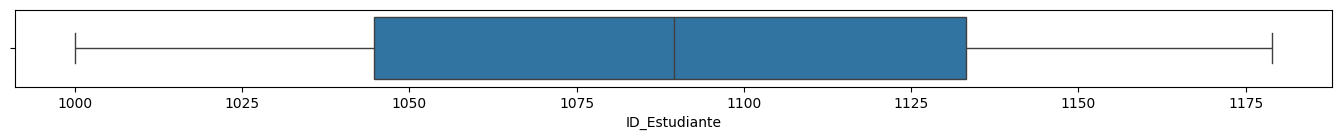

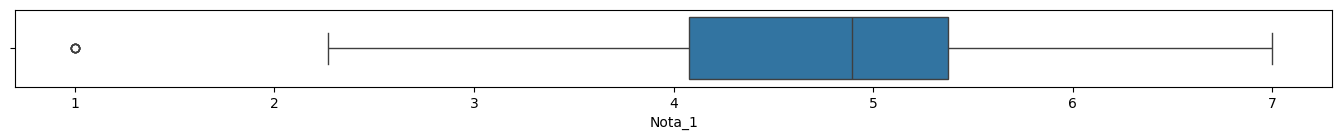

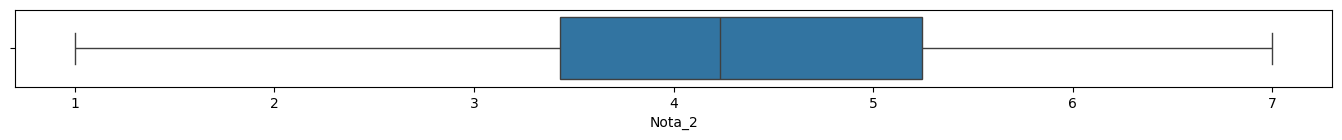

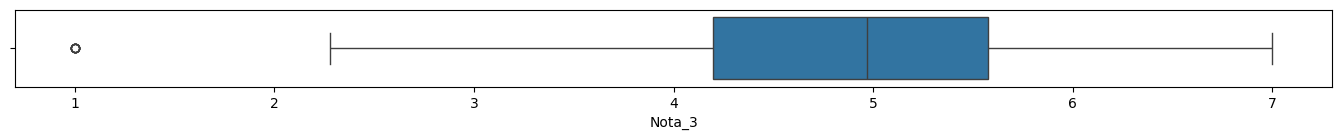

In [14]:
## Creamos diagramas de caja para las variables numéricas para determinar outliers
num_cols=df.select_dtypes(include='number').columns
for col in num_cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=df[num_cols], x=col)

In [15]:
## El Rango Intercuartílico (IQR) es una técnica robusta para detectar valores extremos
# Nº de Outliers usando rango IQR
outliers={}

for col in num_cols:
  Q1 = np.percentile(df[col], 25)
  Q3 = np.percentile(df[col], 75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers[col]= (df[col] > upper_bound).sum() + (df[col]< lower_bound).sum()

print(outliers)

{'ID_Estudiante': np.int64(0), 'Nota_1': np.int64(5), 'Nota_2': np.int64(0), 'Nota_3': np.int64(7)}


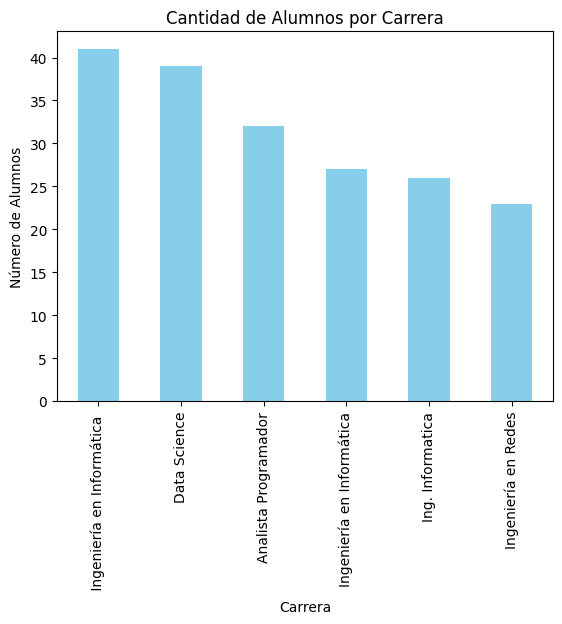

In [16]:
# Grafico de barras (Contamos cuántos alumnos hay en cada carrera)
df['Carrera'].value_counts().plot(kind='bar', color='skyblue')

plt.title('Cantidad de Alumnos por Carrera')
plt.xlabel('Carrera')
plt.ylabel('Número de Alumnos')

plt.show()

In [17]:
print(df['Carrera'].unique())


[' Ingeniería en Informática ' 'Ingeniería en Informática'
 'Analista Programador' 'Data Science' 'Ingeniería en Redes'
 'Ing. Informatica']


In [18]:
# Definimos qué nombres queremos cambiar y por cuál
cambios = {
    'Ingeniería en Informática': 'Ingeniería en Informatíca',
    'Ing. Informatica': 'Ingeniería en Informatíca',
    ' Ingeniería en Informática ': 'Ingeniería en Informatíca'
}

# Aplicamos los cambios a la columna
df['Carrera'] = df['Carrera'].replace(cambios)

#verificamos los cambios
print(df['Carrera'].value_counts())

Carrera
Ingeniería en Informatíca    94
Data Science                 39
Analista Programador         32
Ingeniería en Redes          23
Name: count, dtype: int64


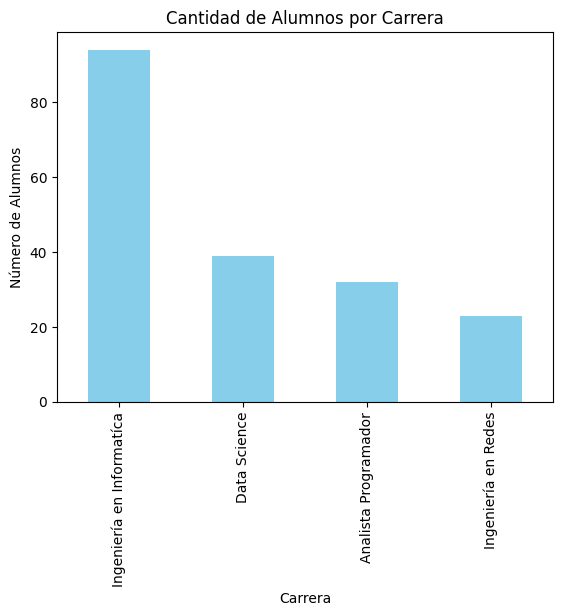

In [19]:
# Grafico de barras (Contamos cuántos alumnos hay en cada carrera)
df['Carrera'].value_counts().plot(kind='bar', color='skyblue')

plt.title('Cantidad de Alumnos por Carrera')
plt.xlabel('Carrera')
plt.ylabel('Número de Alumnos')

plt.show()

In [27]:
# Seleccionamos solo las columnas de las notas y calculamos el promedio
df['promedio'] = df[['Nota_1', 'Nota_2', 'Nota_3']].mean(axis=1).round(1)
print(df.head())

   ID_Estudiante           Nombre                    Carrera Seccion  Nota_1  \
0           1000  Camila González  Ingeniería en Informatíca       C    5.35   
1           1001  Pedro Sepúlveda  Ingeniería en Informatíca       C    6.48   
2           1002  Andrés Martínez       Analista Programador       C    6.54   
3           1003     Isidora Soto               Data Science       A    5.40   
4           1004      Josefa Soto               Data Science       A    5.07   

   Nota_2  Nota_3  promedio  
0    4.43    5.55       5.1  
1    1.00    4.67       4.0  
2    5.52    4.43       5.5  
3    4.04    4.43       4.6  
4    2.30    3.18       3.5  


In [29]:
# Definimos que la nota mínima para pasar es 3.0 (cámbialo si es necesario)
nota_minima = 4.0

df['estado'] = np.where(df['promedio'] >= nota_minima, 'Aprobado', 'Reprobado')

# Ver el resultado
print(df[['Nombre', 'promedio', 'estado']].head())

            Nombre  promedio     estado
0  Camila González       5.1   Aprobado
1  Pedro Sepúlveda       4.0   Aprobado
2  Andrés Martínez       5.5   Aprobado
3     Isidora Soto       4.6   Aprobado
4      Josefa Soto       3.5  Reprobado


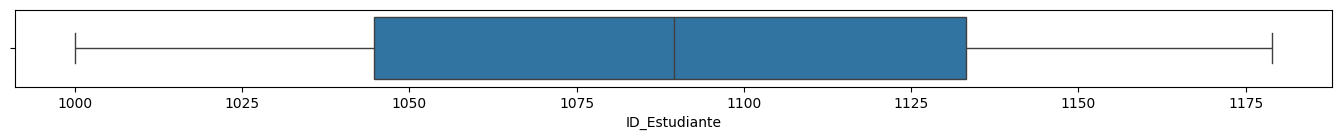

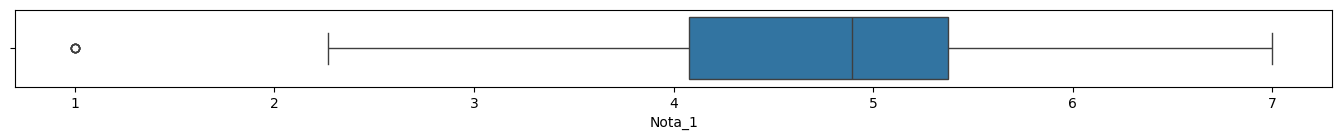

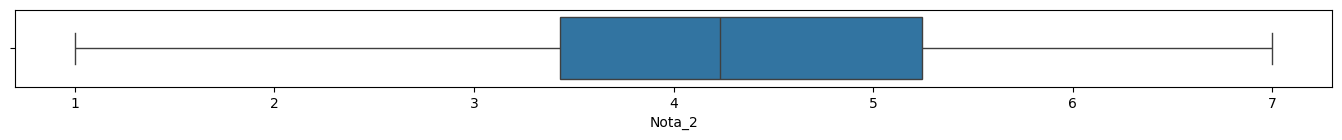

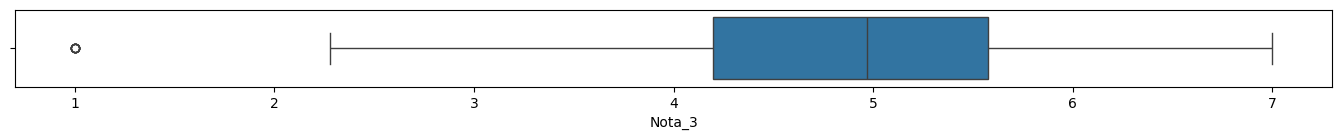

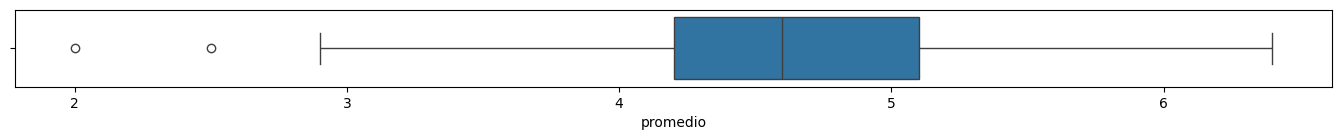

In [30]:
## Creamos diagramas de caja para las variables numéricas para determinar outliers
num_cols=df.select_dtypes(include='number').columns
for col in num_cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=df[num_cols], x=col)